In [ ]:
from google.colab import files
uploaded= files.upload()

Saving predicting-cirrhosis-outcomes.zip to predicting-cirrhosis-outcomes (6).zip


In [ ]:
import zipfile
import os

# Unzip to a new folder
with zipfile.ZipFile("predicting-cirrhosis-outcomes.zip", "r") as zip_ref:
    zip_ref.extractall("cirrhosis_data")

# Check the contents
print(os.listdir("cirrhosis_data"))


['test.csv', 'sample_submission.csv', 'train.csv']


In [ ]:
import pandas as pd

# Load datasets
train = pd.read_csv("cirrhosis_data/train.csv")
test = pd.read_csv("cirrhosis_data/test.csv")
sample_submission = pd.read_csv("cirrhosis_data/sample_submission.csv")

# Preview training data
train.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,0,1690.0,Placebo,16714.0,F,N,Y,Y,N,14.4,514.0,3.16,42.0,2184.0,185.00,126.0,319.0,13.2,4.0,D
1,1,2216.0,D-penicillamine,19327.0,F,Y,Y,N,N,1.3,NaN,3.03,234.0,601.0,135.00,NaN,559.0,11.5,4.0,D
2,2,1725.0,Placebo,12897.0,F,N,N,N,N,0.8,232.0,3.85,9.0,1074.0,128.65,99.0,295.0,9.5,3.0,C
3,3,2468.0,D-penicillamine,20555.0,F,N,N,Y,N,0.5,176.0,3.61,121.0,558.0,96.10,55.0,151.0,11.0,3.0,C
4,4,999.0,D-penicillamine,26580.0,M,N,N,N,N,1.8,318.0,3.52,73.0,721.0,85.25,260.0,NaN,9.6,2.0,C


In [ ]:
test.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,15000,708.0,NaN,18628.0,F,NaN,NaN,NaN,N,3.2,NaN,3.15,NaN,NaN,NaN,NaN,388.0,9.9,3.0
1,15001,971.0,Placebo,19470.0,F,N,N,Y,N,20.0,1276.0,3.04,141.0,2496.0,203.05,157.0,319.0,12.9,4.0
2,15002,1427.0,D-penicillamine,11872.0,F,N,N,N,N,0.5,257.0,3.74,37.0,9009.8,127.00,73.0,283.0,10.4,2.0
3,15003,1097.0,NaN,18993.0,F,NaN,NaN,NaN,N,1.8,NaN,3.20,NaN,NaN,NaN,NaN,117.0,10.7,2.0
4,15004,2103.0,NaN,22797.0,F,NaN,NaN,NaN,S,0.9,NaN,3.75,NaN,NaN,NaN,NaN,226.0,9.9,2.0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15000 non-null  int64  
 1   N_Days         15000 non-null  float64
 2   Drug           8492 non-null   object 
 3   Age            15000 non-null  float64
 4   Sex            15000 non-null  object 
 5   Ascites        8494 non-null   object 
 6   Hepatomegaly   8487 non-null   object 
 7   Spiders        8485 non-null   object 
 8   Edema          15000 non-null  object 
 9   Bilirubin      15000 non-null  float64
 10  Cholesterol    6612 non-null   float64
 11  Albumin        15000 non-null  float64
 12  Copper         8364 non-null   float64
 13  Alk_Phos       8485 non-null   float64
 14  SGOT           8480 non-null   float64
 15  Tryglicerides  6560 non-null   float64
 16  Platelets      14429 non-null  float64
 17  Prothrombin    14979 non-null  float64
 18  Stage 

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   N_Days         10000 non-null  float64
 2   Drug           5631 non-null   object 
 3   Age            10000 non-null  float64
 4   Sex            10000 non-null  object 
 5   Ascites        5637 non-null   object 
 6   Hepatomegaly   5626 non-null   object 
 7   Spiders        5625 non-null   object 
 8   Edema          10000 non-null  object 
 9   Bilirubin      10000 non-null  float64
 10  Cholesterol    4395 non-null   float64
 11  Albumin        10000 non-null  float64
 12  Copper         5554 non-null   float64
 13  Alk_Phos       5628 non-null   float64
 14  SGOT           5626 non-null   float64
 15  Tryglicerides  4360 non-null   float64
 16  Platelets      9638 non-null   float64
 17  Prothrombin    9985 non-null   float64
 18  Stage  

In [ ]:
#Checking for duplicates
train.duplicated().sum()

np.int64(0)

In [ ]:
test.duplicated().sum()

np.int64(0)

In [ ]:
train.nunique()

,0
id,15000
N_Days,548
Drug,2
Age,394
Sex,2
Ascites,3
Hepatomegaly,3
Spiders,2
Edema,3
Bilirubin,116


In [ ]:
test.nunique()

,0
id,10000
N_Days,511
Drug,2
Age,381
Sex,2
Ascites,2
Hepatomegaly,2
Spiders,2
Edema,3
Bilirubin,115


In [ ]:
train.describe()

,id,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,15000.000000,15000.000000,15000.000000,15000.000000,6612.000000,15000.000000,8364.000000,8485.000000,8480.000000,6560.000000,14429.000000,14979.000000,15000.000000
mean,7499.500000,1970.903067,19271.966733,1.881873,324.806745,3.517281,75.857006,1629.738417,106.603055,111.827439,253.632261,10.636691,3.029000
std,4330.271354,1272.532950,3732.634877,2.790137,172.087714,0.372396,74.839986,1836.475288,51.787553,50.801406,93.050690,0.745795,0.883597
min,0.000000,10.000000,244.000000,0.300000,17.200000,1.860000,2.000000,2.770000,0.900000,33.000000,0.900000,9.000000,1.000000
25%,3749.750000,1092.000000,16467.000000,0.600000,239.000000,3.290000,31.000000,721.000000,71.000000,80.000000,182.000000,10.100000,2.000000
50%,7499.500000,1790.000000,19544.000000,0.900000,280.000000,3.570000,52.000000,1072.000000,97.650000,100.000000,249.000000,10.600000,3.000000
75%,11249.250000,2644.000000,22336.000000,1.800000,358.000000,3.770000,89.000000,1653.000000,133.300000,135.000000,312.000000,11.000000,4.000000
max,14999.000000,25569.000000,94306.000000,28.000000,2880.000000,4.640000,588.000000,18733.000000,601.350000,598.000000,721.000000,20.000000,4.000000


In [ ]:
test.describe()

,id,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,10000.00000,10000.000000,10000.000000,10000.000000,4395.000000,10000.000000,5554.000000,5628.000000,5626.000000,4360.000000,9638.000000,9985.000000,10000.00000
mean,19999.50000,1976.658600,19307.626300,1.893320,326.795904,3.526710,75.802125,1597.057498,107.003239,110.899771,253.034831,10.628803,3.03050
std,2886.89568,1317.479875,3699.981664,2.846029,179.812627,0.371546,76.875385,1763.076173,53.008830,50.745091,101.806288,0.742462,0.87832
min,15000.00000,9.000000,1223.000000,0.300000,105.000000,2.000000,1.000000,159.000000,26.350000,33.000000,0.700000,9.000000,1.00000
25%,17499.75000,1097.000000,16501.500000,0.600000,239.000000,3.290000,31.000000,720.000000,71.000000,80.000000,183.000000,10.100000,2.00000
50%,19999.50000,1810.000000,19693.000000,0.900000,277.000000,3.580000,52.000000,1067.500000,97.650000,99.000000,248.000000,10.600000,3.00000
75%,22499.25000,2644.000000,22574.000000,1.800000,360.000000,3.770000,89.000000,1637.000000,130.200000,131.000000,311.000000,11.000000,4.00000
max,24999.00000,25202.000000,29975.000000,28.000000,1775.000000,4.640000,588.000000,19120.800000,1214.000000,598.000000,4453.000000,18.000000,4.00000


In [ ]:
numerical_cols = train.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'Status' in numerical_cols:
    numerical_cols.remove('Status')

categorical_cols = train.select_dtypes(include='object').columns.tolist()
print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)


Numerical: ['id', 'N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']
Categorical: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Status']


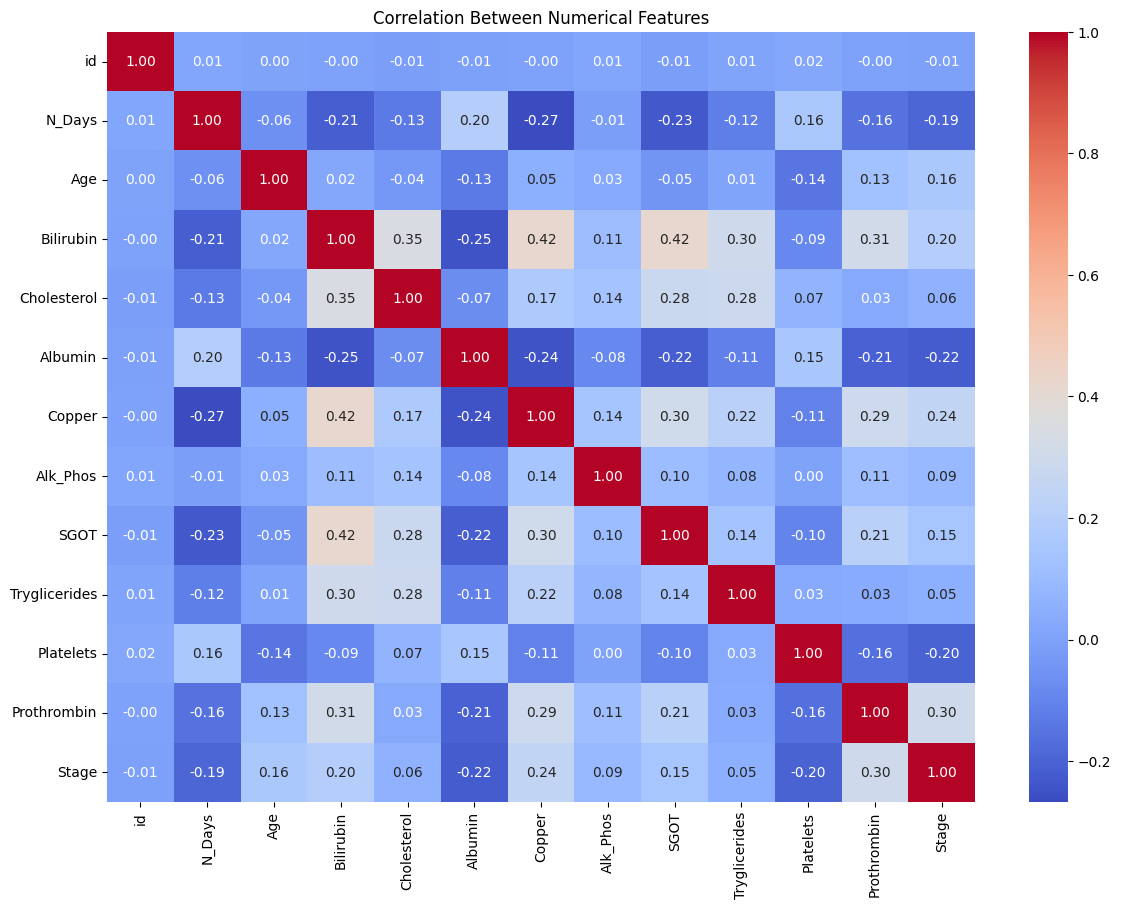

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = train[numerical_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Numerical Features")
plt.show()


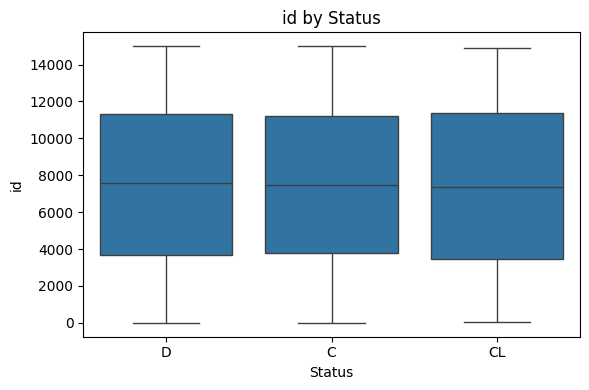

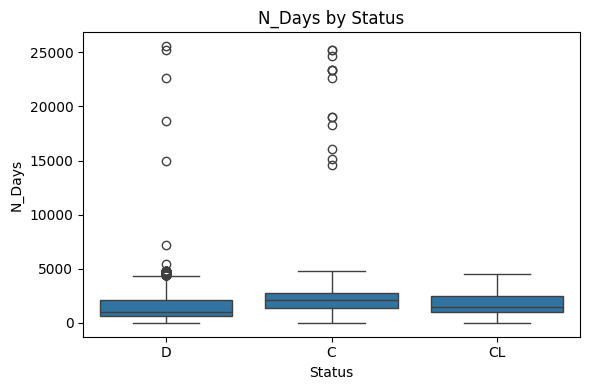

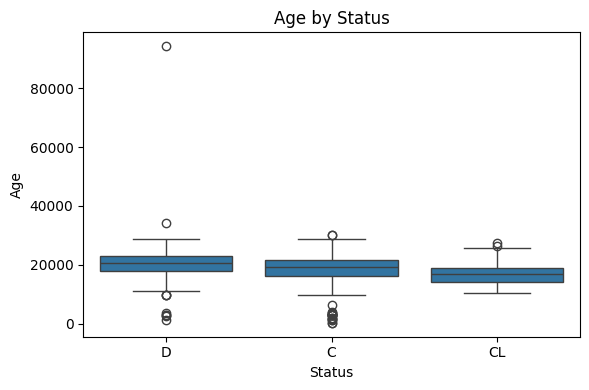

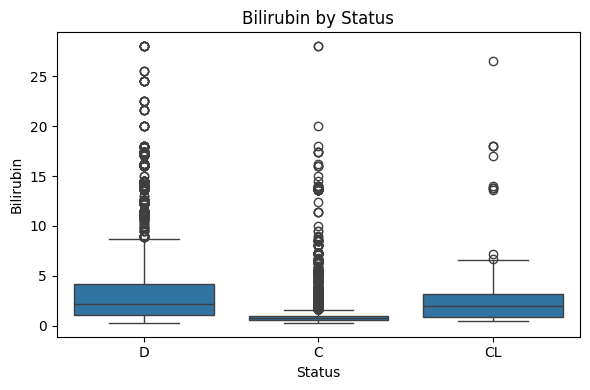

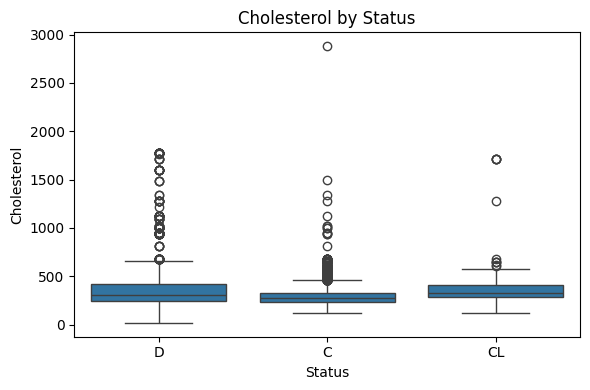

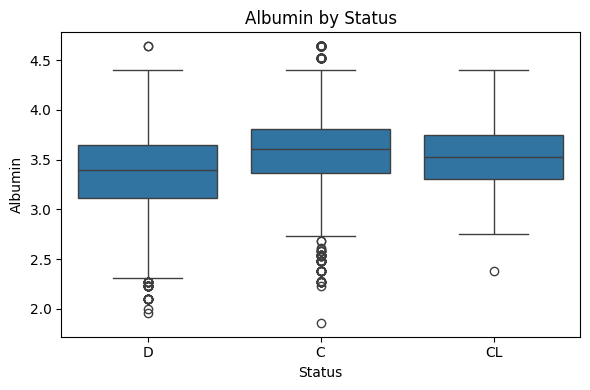

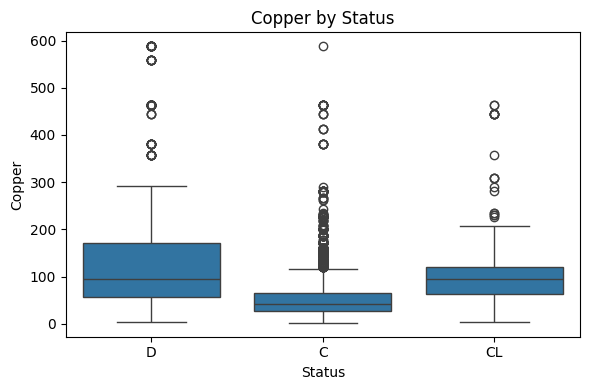

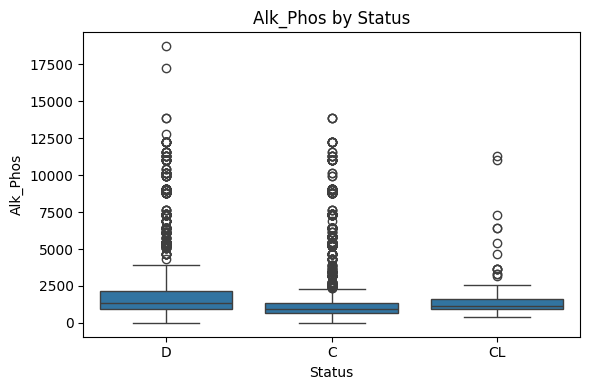

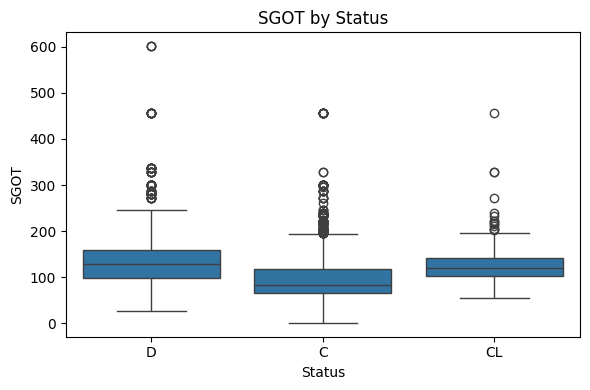

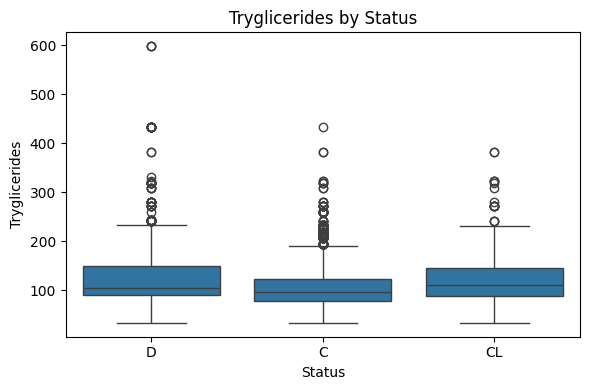

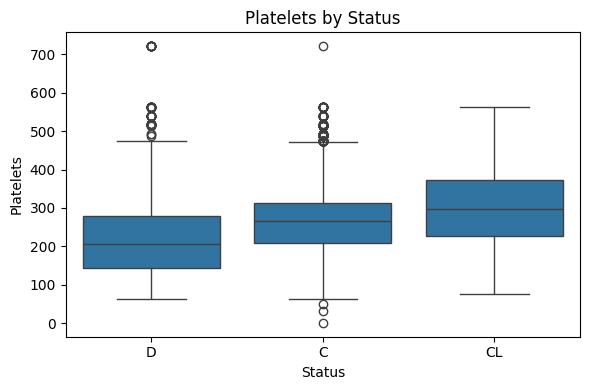

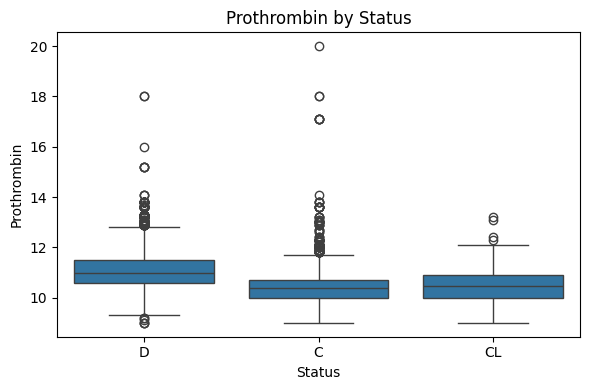

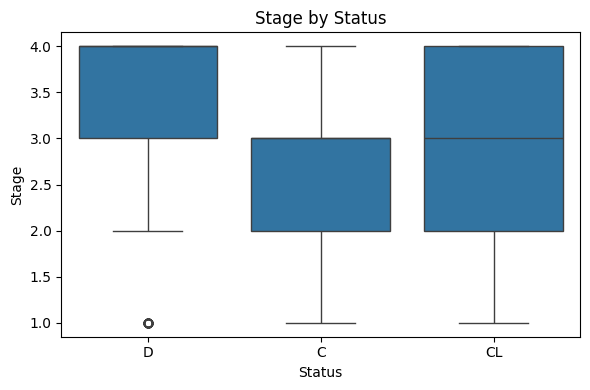

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=train['Status'], y=train[col])
    plt.title(f"{col} by Status")
    plt.tight_layout()
    plt.show()


In [ ]:
# Generate table of missing values
missing_info = train.isnull().sum().reset_index()
missing_info.columns = ['Feature', 'MissingCount']
missing_info = missing_info[missing_info['MissingCount'] > 0]
missing_info['PercentMissing'] = 100 * missing_info['MissingCount'] / len(train)
missing_info.sort_values(by='MissingCount', ascending=False)


,Feature,MissingCount,PercentMissing
15,Tryglicerides,8440,56.266667
10,Cholesterol,8388,55.920000
12,Copper,6636,44.240000
14,SGOT,6520,43.466667
13,Alk_Phos,6515,43.433333
7,Spiders,6515,43.433333
6,Hepatomegaly,6513,43.420000
2,Drug,6508,43.386667
5,Ascites,6506,43.373333
16,Platelets,571,3.806667


In [ ]:
# Quick distribution stats
train[numerical_cols].describe().T[['mean', 'std', 'min', '50%', 'max']]


,mean,std,min,50%,max
id,7499.500000,4330.271354,0.00,7499.50,14999.00
N_Days,1970.903067,1272.532950,10.00,1790.00,25569.00
Age,19271.966733,3732.634877,244.00,19544.00,94306.00
Bilirubin,1.881873,2.790137,0.30,0.90,28.00
Cholesterol,324.806745,172.087714,17.20,280.00,2880.00
Albumin,3.517281,0.372396,1.86,3.57,4.64
Copper,75.857006,74.839986,2.00,52.00,588.00
Alk_Phos,1629.738417,1836.475288,2.77,1072.00,18733.00
SGOT,106.603055,51.787553,0.90,97.65,601.35
Tryglicerides,111.827439,50.801406,33.00,100.00,598.00


In [ ]:
# Skewed features sorted
train[numerical_cols].skew().sort_values(ascending=False)


,0
Cholesterol,4.800551
N_Days,4.682782
Bilirubin,4.173160
Alk_Phos,3.420503
Copper,2.937408
Tryglicerides,2.196546
SGOT,2.065064
Prothrombin,1.702644
Platelets,0.532051
Age,0.261954


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Step 1: Define column groups
target = 'Status'

cat_cols_nominal = ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
cat_cols_ordinal = ['Stage']
num_cols = ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos',
            'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

# Step 2: Conditional Mode Imputation for categorical columns
for col in cat_cols_nominal + cat_cols_ordinal:
    prop = train[col].value_counts(normalize=True)
    fill_values = []

    for value, count in prop.items():
        fill_values.extend([value] * int(count * train[col].isnull().sum()))

    np.random.shuffle(fill_values)

    if len(fill_values) < train[col].isnull().sum():
        fill_values.extend([prop.idxmax()] * (train[col].isnull().sum() - len(fill_values)))
    elif len(fill_values) > train[col].isnull().sum():
        fill_values = fill_values[:train[col].isnull().sum()]

    train.loc[train[col].isnull(), col] = fill_values

# Step 3: Drop rows with missing numerical values
train = train.dropna(subset=num_cols).reset_index(drop=True)

# Step 4: Encode features
nominal_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
train_nominal_encoded = nominal_encoder.fit_transform(train[cat_cols_nominal])
train_nominal_df = pd.DataFrame(train_nominal_encoded, columns=nominal_encoder.get_feature_names_out(cat_cols_nominal))

# Ordinal encode ordinal features
ordinal_encoder = OrdinalEncoder()
train_ordinal_encoded = ordinal_encoder.fit_transform(train[cat_cols_ordinal])
train_ordinal_df = pd.DataFrame(train_ordinal_encoded, columns=cat_cols_ordinal)

# Step 5: Combine encoded + numerical columns
train_processed = pd.concat([train[num_cols].reset_index(drop=True),
                             train_nominal_df.reset_index(drop=True),
                             train_ordinal_df.reset_index(drop=True)], axis=1)

# Step 6: Encode labels
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(train[target])  # e.g., C = 0, CL = 1, D = 2

# Step 7: Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(train_processed, y_train)

In [ ]:
#3 Kaggle Solution's ADS
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

classifiers = {
    'AdaBoost': AdaBoostClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    'RandomForest': RandomForestClassifier()
}

param_grids = {
    'AdaBoost': {
        'n_estimators': [100],
        'learning_rate': [0.1]
    },
    'XGBoost': {
        'n_estimators': [100],
        'max_depth': [6],
        'learning_rate': [0.1]
    },
    'RandomForest': {
        'n_estimators': [100],
        'max_depth': [10],
        'min_samples_split': [5],
        'min_samples_leaf': [2]
    }
}

best_models = {}
best_logloss = float('inf')
best_model_name = None

for clf_name, clf in classifiers.items():
    print(f"Training {clf_name}...")
    grid_search = GridSearchCV(clf, param_grids[clf_name], cv=5, scoring='neg_log_loss', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_models[clf_name] = grid_search.best_estimator_
    score = -grid_search.best_score_
    if score < best_logloss:
        best_logloss = score
        best_model_name = clf_name

best_model = best_models[best_model_name]
probs = best_model.predict_proba(X_val)
preds = np.argmax(probs, axis=1)

Training AdaBoost...
Training XGBoost...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:19:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training RandomForest...


In [ ]:
#code to define all required variables for test_processed
# 1. Define columns
cat_cols_nominal = ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
cat_cols_ordinal = ['Stage']
num_cols = ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
            'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

# 2. Scale numeric features
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

# 3. Encode nominal features
from sklearn.preprocessing import OneHotEncoder
nominal_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

train_nominal_encoded = nominal_encoder.fit_transform(train[cat_cols_nominal])
test_nominal_encoded = nominal_encoder.transform(test[cat_cols_nominal])

train_nominal_df = pd.DataFrame(train_nominal_encoded, columns=nominal_encoder.get_feature_names_out(cat_cols_nominal))
test_nominal_df = pd.DataFrame(test_nominal_encoded, columns=nominal_encoder.get_feature_names_out(cat_cols_nominal))

# 4. Encode ordinal features
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()

train_ordinal_encoded = ordinal_encoder.fit_transform(train[cat_cols_ordinal])
test_ordinal_encoded = ordinal_encoder.transform(test[cat_cols_ordinal])

train_ordinal_df = pd.DataFrame(train_ordinal_encoded, columns=cat_cols_ordinal)
test_ordinal_df = pd.DataFrame(test_ordinal_encoded, columns=cat_cols_ordinal)

# 5. Concatenate all processed features
train_processed = pd.concat([train[num_cols], train_nominal_df, train_ordinal_df], axis=1)
test_processed = pd.concat([test[num_cols], test_nominal_df, test_ordinal_df], axis=1)


In [ ]:
#4a overall accuracy metrics
from sklearn.metrics import log_loss, accuracy_score, brier_score_loss
import numpy as np
import pandas as pd

# One-hot encode true labels
y_true_oh = pd.get_dummies(y_val)
y_true_labels = y_val

# 1. Log loss
logloss = log_loss(y_true_oh, probs)

# 2. Brier score
brier = np.mean(np.sum((y_true_oh.values - probs) ** 2, axis=1))

# 3. Top-1 accuracy
accuracy = accuracy_score(y_true_labels, preds)

# 4. Print results
print("4a — Overall ADS Accuracy Metrics")
print(f"Log Loss:      {logloss:.4f}")
print(f"Brier Score:   {brier:.4f}")
print(f"Top-1 Accuracy:{accuracy:.4f}")

4a — Overall ADS Accuracy Metrics
Log Loss:      0.2668
Brier Score:   0.1466
Top-1 Accuracy:0.9017


In [ ]:
# Step 1: Limit to real (non-synthetic) rows
original_n = len(train_processed)
X_real = X_resampled[:original_n]
y_real = y_resampled[:original_n]

# Step 2: Get matching metadata
audit_metadata = train.copy().reset_index(drop=True)  # includes Sex, Stage, Drug

# Step 3: Split real data and metadata together
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val, meta_train, audit_df = train_test_split(
    X_real, y_real, audit_metadata, test_size=0.2, random_state=42
)


In [ ]:
# Get predictions
probs = best_model.predict_proba(X_val)
preds = best_model.predict(X_val)

# Attach results to audit_df
audit_df = audit_df.reset_index(drop=True)
audit_df['true_label'] = target_encoder.inverse_transform(y_val)
audit_df['pred_label'] = target_encoder.inverse_transform(preds)
audit_df[['prob_C', 'prob_CL', 'prob_D']] = probs


In [ ]:
#4a accuracy metrics for subpopulations

label_map = {'C': 0, 'CL': 1, 'D': 2}
audit_df['true_numeric'] = audit_df['true_label'].map(label_map)

def subgroup_metrics(df, group_col):
    results = []
    for group in df[group_col].dropna().unique():
        subset = df[df[group_col] == group]
        if len(subset) < 50:
            continue
        y_true_bin = pd.get_dummies(subset['true_numeric'])
        y_pred_probs = subset[['prob_C', 'prob_CL', 'prob_D']]
        logloss = log_loss(y_true_bin, y_pred_probs)
        acc = accuracy_score(subset['true_label'], subset['pred_label'])
        results.append((group, len(subset), round(logloss, 4), round(acc, 4)))
    return pd.DataFrame(results, columns=[group_col, 'n', 'log_loss', 'top1_accuracy'])

print("Accuracy by Sex:")
print(subgroup_metrics(audit_df, 'Sex'))

print("\nAccuracy by Stage:")
print(subgroup_metrics(audit_df, 'Stage'))

print("\nAccuracy by Drug:")
print(subgroup_metrics(audit_df, 'Drug'))


Accuracy by Sex:
  Sex     n  log_loss  top1_accuracy
0   F  1183    0.2469         0.9180
1   M    70    0.3467         0.8857

Accuracy by Stage:
   Stage    n  log_loss  top1_accuracy
0    4.0  422    0.2962         0.9100
1    3.0  506    0.2683         0.9051
2    2.0  248    0.2104         0.9234
3    1.0   77    0.0447         1.0000

Accuracy by Drug:
              Drug    n  log_loss  top1_accuracy
0          Placebo  644    0.2624         0.9146
1  D-penicillamine  609    0.2420         0.9179


In [ ]:
#4b fairness metrics
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Demographic Parity
def demographic_parity(df, group_col):
    return df.groupby([group_col, 'pred_label']).size().unstack(fill_value=0).apply(lambda x: x / x.sum(), axis=1)

# 2. Equalized Odds
def equalized_odds(df, group_col, class_label):
    subset = df[df['true_label'] == class_label]
    return subset.groupby(group_col).apply(lambda g: (g['pred_label'] == class_label).mean()).rename(f'TPR_{class_label}')

# 3. Calibration by Group
def calibration_by_group(df, group_col, class_col='prob_D', class_label='D'):
    return df.groupby(group_col).apply(
        lambda g: pd.Series({
            'avg_pred_prob': g[class_col].mean(),
            'actual_freq': (g['true_label'] == class_label).mean()
        })
    )

# Run metrics by Sex
print("Demographic Parity (Sex):")
print(demographic_parity(audit_df, 'Sex'))

print("\nEqualized Odds (TPR for Class D by Sex):")
print(equalized_odds(audit_df, 'Sex', class_label='D'))

print("\nCalibration by Group (Sex, Class D):")
print(calibration_by_group(audit_df, 'Sex', class_col='prob_D', class_label='D'))


Demographic Parity (Sex):
pred_label         C        CL         D
Sex                                     
F           0.704987  0.030431  0.264582
M           0.357143  0.057143  0.585714

Equalized Odds (TPR for Class D by Sex):
Sex
F    0.841791
M    0.902439
Name: TPR_D, dtype: float64

Calibration by Group (Sex, Class D):
     avg_pred_prob  actual_freq
Sex                            
F         0.280832     0.283178
M         0.574310     0.585714


<ipython-input-116-7967c1c64621>:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return subset.groupby(group_col).apply(lambda g: (g['pred_label'] == class_label).mean()).rename(f'TPR_{class_label}')
<ipython-input-116-7967c1c64621>:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_col).apply(


In [ ]:
#4c additional methods: assessing stability & robustness
import numpy as np
import pandas as pd
from sklearn.metrics import log_loss, accuracy_score

# Step 1: Compute model confidence (max predicted class probability)
audit_df['confidence'] = audit_df[['prob_C', 'prob_CL', 'prob_D']].max(axis=1)

# Step 2: Define high-uncertainty subset (lowest 10% confidence)
threshold = audit_df['confidence'].quantile(0.10)
uncertain_df = audit_df[audit_df['confidence'] <= threshold]
certain_df = audit_df[audit_df['confidence'] > threshold]

# Step 3: Convert true labels to numeric for log loss
label_map = {'C': 0, 'CL': 1, 'D': 2}
audit_df['true_numeric'] = audit_df['true_label'].map(label_map)
uncertain_df['true_numeric'] = uncertain_df['true_label'].map(label_map)
certain_df['true_numeric'] = certain_df['true_label'].map(label_map)

# Step 4: Compute performance metrics
def evaluate(df):
    y_true_bin = pd.get_dummies(df['true_numeric'])
    y_pred_probs = df[['prob_C', 'prob_CL', 'prob_D']]
    acc = accuracy_score(df['true_label'], df['pred_label'])
    loss = log_loss(y_true_bin, y_pred_probs)
    return round(loss, 4), round(acc, 4)

logloss_uncertain, acc_uncertain = evaluate(uncertain_df)
logloss_certain, acc_certain = evaluate(certain_df)

print("Uncertain Predictions (Lowest 10% Confidence):")
print(f"Log Loss: {logloss_uncertain}, Top-1 Accuracy: {acc_uncertain}")

print("\nAll Other Predictions:")
print(f"Log Loss: {logloss_certain}, Top-1 Accuracy: {acc_certain}")


Uncertain Predictions (Lowest 10% Confidence):
Log Loss: 0.7783, Top-1 Accuracy: 0.6429

All Other Predictions:
Log Loss: 0.1937, Top-1 Accuracy: 0.9468


<ipython-input-117-7e5c582b9114>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uncertain_df['true_numeric'] = uncertain_df['true_label'].map(label_map)
<ipython-input-117-7e5c582b9114>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  certain_df['true_numeric'] = certain_df['true_label'].map(label_map)


  0%|          | 0/50 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

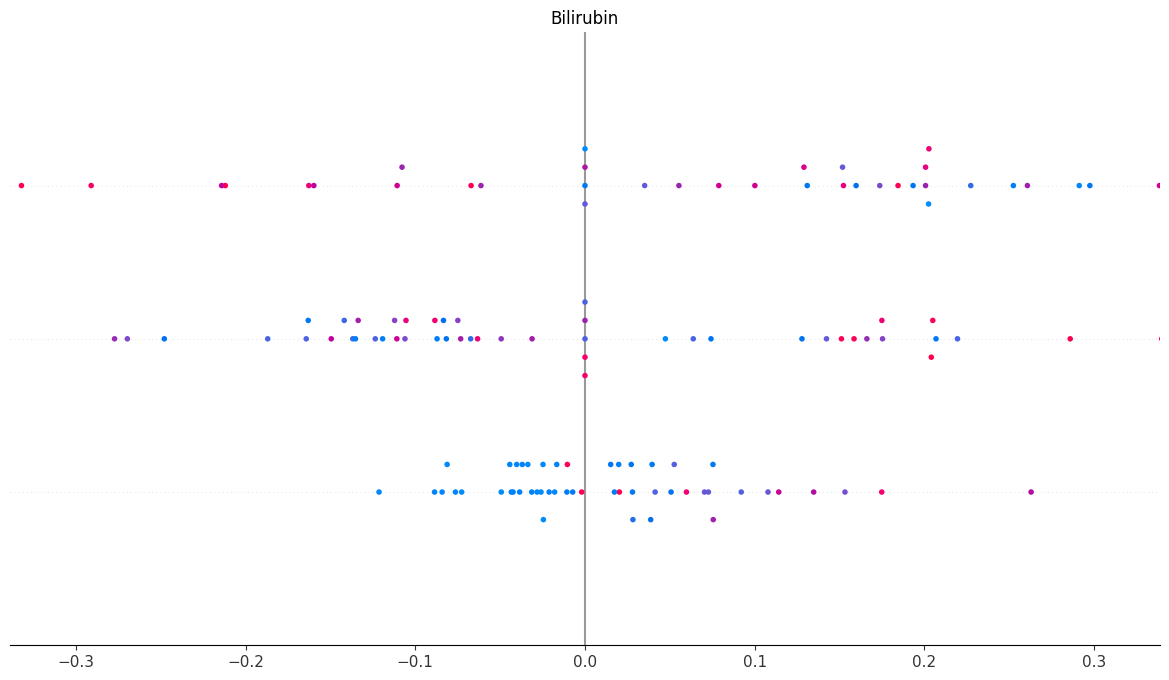

In [ ]:
#4c: additional methods (SHAP)

import shap
import numpy as np

# Step 1: Convert validation and training sets to NumPy arrays
X_val_array = np.array(X_val)
X_train_array = np.array(X_train)

# Step 2: Define a wrapper for predict_proba to avoid attribute error
def predict_proba_wrapper(X):
    return best_model.predict_proba(X)

# Step 3: Use a small background set for efficiency
explainer_shap = shap.KernelExplainer(predict_proba_wrapper, X_train_array[:100])

# Step 4: Compute SHAP values for the first 50 validation samples
shap_values = explainer_shap.shap_values(X_val_array[:50])

# Step 5: Plot SHAP summary plot for class 2 (death = D)
shap.summary_plot(shap_values, X_val_array[:50], feature_names=X_resampled.columns)


In [ ]:
#4c: additional methods (LIME)
!pip install lime
import lime
import lime.lime_tabular

# Step 1: Initialize LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_array,
    feature_names=X_resampled.columns,
    class_names=target_encoder.classes_,
    mode='classification'
)

# Step 2: Choose an index from the validation set to explain
i = 0

# Step 3: Generate and display the explanation
lime_exp = lime_explainer.explain_instance(X_val_array[i], best_model.predict_proba)
lime_exp.show_in_notebook()



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=2bc4d2e909d113a61879f2978f90e06832059ff2b4da0fa04488ebbd43e884ed
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime
